In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D,BatchNormalization,Cropping2D
from tensorflow.keras.models import Model
import random
import tensorflow as tf
from tensorflow.keras import backend as K
from scipy.ndimage import distance_transform_edt


2025-07-16 11:59:13.366132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752667153.657842      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752667153.749047      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Đọc tệp Excel vào DataFrame
file_path = "/kaggle/input/daaset/data/classification.xlsx"  # Đường dẫn đến file Excel
df = pd.read_excel(file_path)

# Đường dẫn thư mục ảnh và mask
image_path = '/kaggle/input/daaset/data/images'
mask_path = '/kaggle/input/daaset/data/masks'
print("a1")

a1


In [3]:
!pip install openpyxl

In [4]:
from sklearn.model_selection import train_test_split

df_t=df[df['mask_flag'] == 1].copy()
# Lọc những ảnh có mask
df_train, df_temp = train_test_split(
    df_t, 
    test_size=0.3, 
    random_state=42, 
    shuffle=True, 
    stratify=df_t['tumor_type']
)

# Bước 2: Chia temp thành val (15%) và test (15%) cũng stratify theo tumor_type
df_valid, df_test = train_test_split(
    df_temp, 
    test_size=0.5, 
    random_state=42, 
    shuffle=True, 
    stratify=df_temp['tumor_type']
)

print("Train:", len(df_train), "Validation:", len(df_valid), "Test:", len(df_test))

# Kiểm tra số lượng từng loại trong mỗi tập
print("Train tumor type distribution:\n", df_train['tumor_type'].value_counts())
print("Validation tumor type distribution:\n", df_valid['tumor_type'].value_counts())
print("Test tumor type distribution:\n", df_test['tumor_type'].value_counts())

Train: 1306 Validation: 280 Test: 281
Train tumor type distribution:
 tumor_type
osteochondroma              527
osteosarcoma                208
multiple osteochondromas    184
simple bone cyst            144
other bt                     80
giant cell tumor             65
synovial osteochondroma      35
other mt                     32
osteofibroma                 31
Name: count, dtype: int64
Validation tumor type distribution:
 tumor_type
osteochondroma              113
osteosarcoma                 44
multiple osteochondromas     39
simple bone cyst             31
other bt                     17
giant cell tumor             14
synovial osteochondroma       8
other mt                      7
osteofibroma                  7
Name: count, dtype: int64
Test tumor type distribution:
 tumor_type
osteochondroma              114
osteosarcoma                 45
multiple osteochondromas     40
simple bone cyst             31
other bt                     18
giant cell tumor             14
synovial 

In [5]:
# Tạo cột đường dẫn
df_train['image_path'] = df_train['image_id'].apply(lambda x: os.path.join(image_path, f"{os.path.splitext(x)[0]}.jpg"))
df_train['mask_path']  = df_train['image_id'].apply(lambda x: os.path.join(mask_path, f"{os.path.splitext(x)[0]}.png"))

df_test['image_path'] = df_test['image_id'].apply(lambda x: os.path.join(image_path, f"{os.path.splitext(x)[0]}.jpg"))
df_test['mask_path']  = df_test['image_id'].apply(lambda x: os.path.join(mask_path, f"{os.path.splitext(x)[0]}.png"))

df_valid['image_path'] = df_valid['image_id'].apply(lambda x: os.path.join(image_path, f"{os.path.splitext(x)[0]}.jpg"))
df_valid['mask_path']  = df_valid['image_id'].apply(lambda x: os.path.join(mask_path, f"{os.path.splitext(x)[0]}.png"))

print("a1")

a1


In [6]:
def create_distance_map_np(mask_np):
    fg = mask_np[..., 1]  # lớp foreground (đã one-hot)
    dist_out = distance_transform_edt(1 - fg)
    dist_in = distance_transform_edt(fg)
    dist_map = dist_out - dist_in

    max_val = np.max(np.abs(dist_map))
    if max_val > 0:
        dist_map = dist_map / max_val  # chuẩn hóa về [-1, 1]

    return dist_map.astype(np.float32)

def create_distance_map_tf(mask):
    dist_map = tf.py_function(func=create_distance_map_np, inp=[mask], Tout=tf.float32)
    dist_map = tf.reshape(dist_map, [256, 256])  # Gán shape rõ ràng
    dist_map = tf.expand_dims(dist_map, axis=-1)  # (H, W, 1)
    return dist_map

print("Done")

Done


In [7]:
import tensorflow as tf
import random
    
# Hàm load ảnh và mask (bỏ comment, dùng bình thường)
def load_image_and_mask(image_path, mask_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, [256, 256])
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256], method='nearest')
    mask = tf.cast(mask > 0, tf.uint8)  # <- Rất quan trọng: đưa mọi giá trị khác 0 về 1
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=2)

    return image, mask

def load_image_mask_distance(image_path, mask_path):
    image, mask = load_image_and_mask(image_path, mask_path)
    distance_map = create_distance_map_tf(mask)
    return image, {'mask_output': mask, 'distance_output': distance_map}
    
    
def random_augment(image, mask):
    # Lật ngang
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Dịch chuyển
    if tf.random.uniform(()) > 0.5:
        shift = tf.random.uniform(shape=[2], minval=-10, maxval=10, dtype=tf.int32)
        image = tf.roll(image, shift=shift, axis=[0, 1])
        mask = tf.roll(mask, shift=shift, axis=[0, 1])

    return image, mask

def load_image_mask_distance_with_aug(image_path, mask_path):
    image, mask = load_image_and_mask(image_path, mask_path)

    # Augment ảnh và mask
    image, mask = random_augment(image, mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_brightness(image, 0.1)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_contrast(image, 0.8, 1.2)

    # Tính distance map từ mask đã augment
    distance_map = create_distance_map_tf(mask)

    return image, {'mask_output': mask, 'distance_output': distance_map}


# Chọn batch size cố định hoặc random
BATCH_SIZE = 4  # hoặc random.choice([8]) nếu muốn random

if not df_train.empty:
    train_dataset = tf.data.Dataset.from_tensor_slices((df_train['image_path'], df_train['mask_path']))
    train_dataset = train_dataset.map(load_image_mask_distance_with_aug, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.shuffle(buffer_size=1000)
    train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
else:
    train_dataset = None

if not df_valid.empty:
    val_dataset = tf.data.Dataset.from_tensor_slices((df_valid['image_path'], df_valid['mask_path']))
    val_dataset = val_dataset.map(load_image_mask_distance, num_parallel_calls=tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(16).prefetch(tf.data.AUTOTUNE)
else:
    val_dataset = None

if not df_test.empty:
    test_dataset = tf.data.Dataset.from_tensor_slices((df_test['image_path'], df_test['mask_path']))
    test_dataset = test_dataset.map(load_image_mask_distance, num_parallel_calls=tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(16).prefetch(tf.data.AUTOTUNE)
else:
    test_dataset = None
print("Datasets prepared.")


I0000 00:00:1752667173.604249      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets prepared.


Train batch shape:
Image batch shape: (4, 256, 256, 1)
Mask batch shape: (4, 256, 256, 2)
Distance map shape: (4, 256, 256, 1)


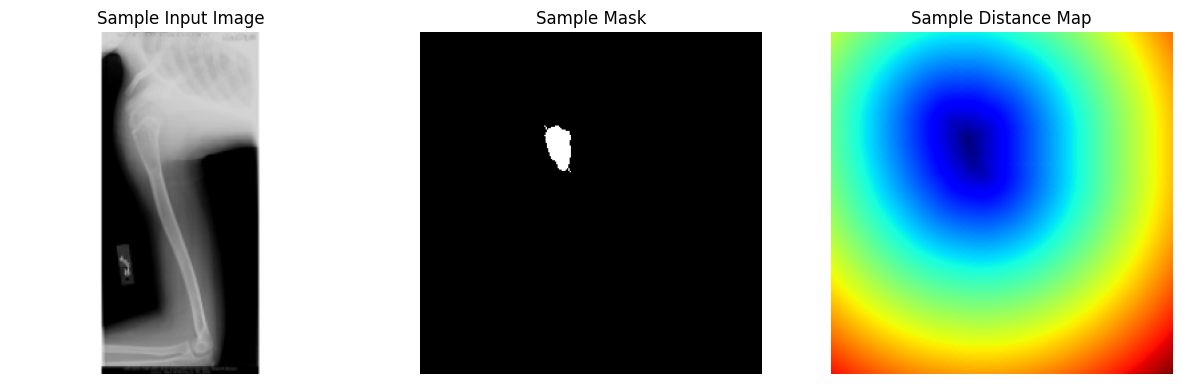

Validation batch shape:
Image batch shape: (16, 256, 256, 1)
Mask batch shape: (16, 256, 256, 2)
Distance map shape: (16, 256, 256, 1)


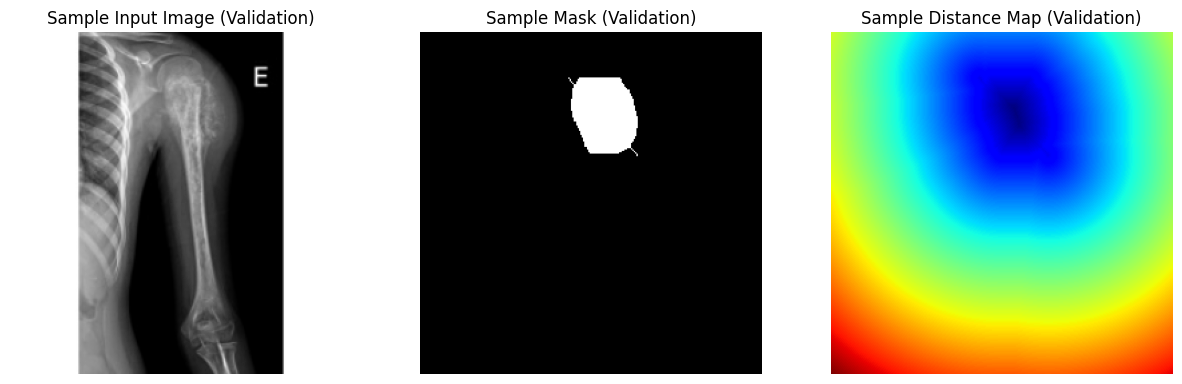

Test batch shape:
Image batch shape: (16, 256, 256, 1)
Mask batch shape: (16, 256, 256, 2)
Distance map shape: (16, 256, 256, 1)


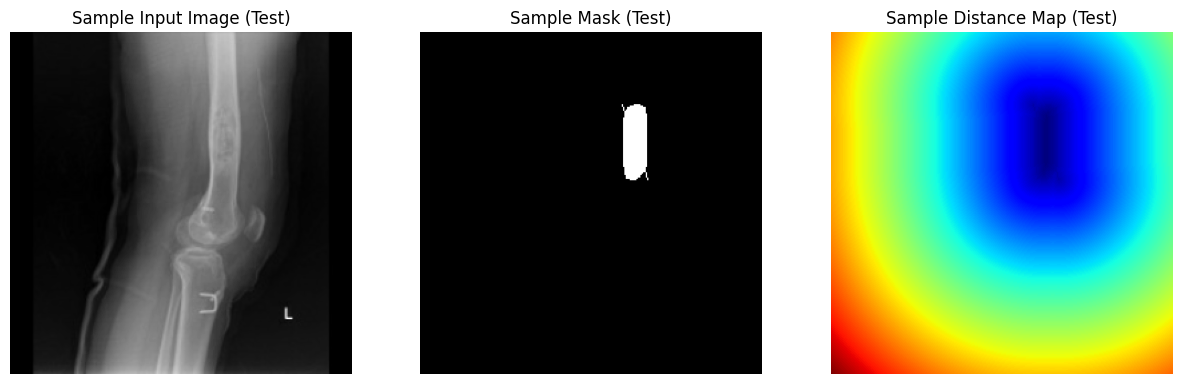

In [8]:
import matplotlib.pyplot as plt

# Train set
for images, labels in train_dataset.take(1):
    print("Train batch shape:")
    print("Image batch shape:", images.shape)  # (B, 256, 256, 1)
    print("Mask batch shape:", labels['mask_output'].shape)  # (B, 256, 256, 2)
    print("Distance map shape:", labels['distance_output'].shape)  # (B, 256, 256, 1)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(images[0, :, :, 0], cmap='gray')
    plt.title("Sample Input Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(labels['mask_output'][0, :, :, 1], cmap='gray')  # foreground mask
    plt.title("Sample Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(labels['distance_output'][0, :, :, 0], cmap='jet')
    plt.title("Sample Distance Map")
    plt.axis('off')

    plt.show()
    break

# Validation set
for images, labels in val_dataset.take(1):
    print("Validation batch shape:")
    print("Image batch shape:", images.shape)
    print("Mask batch shape:", labels['mask_output'].shape)
    print("Distance map shape:", labels['distance_output'].shape)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(images[0, :, :, 0], cmap='gray')
    plt.title("Sample Input Image (Validation)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(labels['mask_output'][0, :, :, 1], cmap='gray')
    plt.title("Sample Mask (Validation)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(labels['distance_output'][0, :, :, 0], cmap='jet')
    plt.title("Sample Distance Map (Validation)")
    plt.axis('off')

    plt.show()
    break

# Test set
for images, labels in test_dataset.take(1):
    print("Test batch shape:")
    print("Image batch shape:", images.shape)
    print("Mask batch shape:", labels['mask_output'].shape)
    print("Distance map shape:", labels['distance_output'].shape)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(images[0, :, :, 0], cmap='gray')
    plt.title("Sample Input Image (Test)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(labels['mask_output'][0, :, :, 1], cmap='gray')
    plt.title("Sample Mask (Test)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(labels['distance_output'][0, :, :, 0], cmap='jet')
    plt.title("Sample Distance Map (Test)")
    plt.axis('off')

    plt.show()
    break


In [9]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
import tensorflow as tf

def segnet_multitask(input_shape=(256, 256, 1), num_classes=2):
    inputs = Input(shape=input_shape)

    # Encoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Decoder
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = UpSampling2D((2, 2))(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = Dropout(0.3)(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = UpSampling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = Dropout(0.3)(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Outputs: 2 đầu ra
    mask_output = Conv2D(num_classes, (1,1), activation='softmax', name='mask_output')(x)
    distance_output = Conv2D(1, (1,1), activation='sigmoid', name='distance_output')(x)

    model = Model(inputs=inputs, outputs=[mask_output, distance_output])
    return model

# Tạo model multitask đúng
model = segnet_multitask(input_shape=(256, 256, 1), num_classes=2)

def weighted_dice_loss(y_true, y_pred, class_weights=[0.2, 0.8]):
    smooth = 1e-6
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    dice = 0
    for i in range(len(class_weights)):
        y_true_f = K.flatten(y_true[..., i])
        y_pred_f = K.flatten(y_pred[..., i])
        intersection = K.sum(y_true_f * y_pred_f)
        union = K.sum(y_true_f) + K.sum(y_pred_f)
        dice_score = (2. * intersection + smooth) / (union + smooth)
        dice += class_weights[i] * (1 - dice_score)
    return dice

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred)
    return (2. * intersection + smooth) / (union + smooth)

# Compile phải có loss, metrics cho từng output, ví dụ:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss={
        'mask_output': weighted_dice_loss,
        'distance_output': 'mse'
    },
    loss_weights={
        'mask_output': 1.0,
        'distance_output': 0.5
    },
    metrics={
        'mask_output': [dice_coef, tf.keras.metrics.MeanIoU(num_classes=2)],
        'distance_output': ['mse']
    }
)

In [10]:
epochs = 300

history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    verbose=1
)
print("✅ Quá trình huấn luyện hoàn tất!")


Epoch 1/300


I0000 00:00:1752667211.437058      97 service.cc:148] XLA service 0x7aaa1c002a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752667211.438271      97 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1752667213.288005      97 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1752667217.477104      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752667217.733607      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/327 ━━━━━━━━━━━━━━━━━━━━ 3:57:47 44s/step - distance_output_loss: 0.1242 - distance_output_mse: 0.1242 - loss: 0.8655 - mask_output_dice_coef: 0.5045 - mask_output_loss: 0.8034 - mask_output_mean_io_u: 0.2500

I0000 00:00:1752667230.127472      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


327/327 ━━━━━━━━━━━━━━━━━━━━ 103s 182ms/step - distance_output_loss: 0.0551 - distance_output_mse: 0.0551 - loss: 0.7665 - mask_output_dice_coef: 0.7885 - mask_output_loss: 0.7390 - mask_output_mean_io_u: 0.2363 - val_distance_output_loss: 0.0471 - val_distance_output_mse: 0.0470 - val_loss: 0.8195 - val_mask_output_dice_coef: 0.9830 - val_mask_output_loss: 0.7960 - val_mask_output_mean_io_u: 0.2500
Epoch 2/300
327/327 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - distance_output_loss: 0.0360 - distance_output_mse: 0.0360 - loss: 0.7129 - mask_output_dice_coef: 0.8923 - mask_output_loss: 0.6949 - mask_output_mean_io_u: 0.2329 - val_distance_output_loss: 0.0427 - val_distance_output_mse: 0.0426 - val_loss: 0.7443 - val_mask_output_dice_coef: 0.7915 - val_mask_output_loss: 0.7225 - val_mask_output_mean_io_u: 0.2073
Epoch 3/300
327/327 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - distance_output_loss: 0.0341 - distance_output_mse: 0.0341 - loss: 0.6744 - mask_output_dice_coef: 0.9238 - mask_output_loss: 0

In [11]:
model.save("segnet_multitask_final.h5")
model.save('/kaggle/working//n1.h5') 

In [12]:
results = model.evaluate(test_dataset)
print("📊 Test results:", results)

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - distance_output_loss: 0.0273 - distance_output_mse: 0.0273 - loss: 0.2522 - mask_output_dice_coef: 0.9902 - mask_output_loss: 0.2386 - mask_output_mean_io_u: 0.6411

E0000 00:00:1752678300.734927      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752678300.969713      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752678301.654893      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752678301.913353      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 547ms/step - distance_output_loss: 0.0273 - distance_output_mse: 0.0273 - loss: 0.2550 - mask_output_dice_coef: 0.9901 - mask_output_loss: 0.2414 - mask_output_mean_io_u: 0.6413
📊 Test results: [0.27841269969940186, 0.265550822019577, 0.027402712032198906, 0.027444247156381607, 0.9894827604293823, 0.6427273750305176]
